# J2 — analyse exploratoire et corrélations

Ce carnet est destiné à l’exploration graphique et statistique des corrélations dans les jeux de données FAO.

## 🎯 Objectifs
- Décrire les distributions des variables clés du dataset global.
- Identifier les pays et régions les plus affectés par la sous-nutrition.
- Mettre en évidence les disparités de disponibilité alimentaire.
- Conduire au moins deux analyses de corrélation avec tests statistiques.
- Interpréter les résultats en langage métier pour le commanditaire.

In [5]:
# 1. Imports & chargement du dataset global

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

sns.set(style="whitegrid")

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "global_fao_dataset.csv")
# création d'un alias simple pour la disponibilité calorique totale
if "Kcal_total_kcal_per_capita_per_day" in df.columns:
    df["Kcal_total"] = df["Kcal_total_kcal_per_capita_per_day"]


# 2.Visualisation du dataset

In [6]:
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Code zone                           175 non-null    int64  
 1   Zone                                175 non-null    str    
 2   Kcal_veg                            175 non-null    float64
 3   Kcal_anim                           175 non-null    float64
 4   Kcal_total_kcal_per_capita_per_day  175 non-null    float64
 5   Population_milliers                 175 non-null    int64  
 6   Sous_alimentation_millions          99 non-null     float64
 7   Population_millions                 175 non-null    float64
 8   Taux_sous_nutrition_pct             99 non-null     float64
 9   Kcal_total                          175 non-null    float64
dtypes: float64(7), int64(2), str(1)
memory usage: 13.8 KB


,Code zone,Kcal_veg,Kcal_anim,Kcal_total_kcal_per_capita_per_day,Population_milliers,Sous_alimentation_millions,Population_millions,Taux_sous_nutrition_pct,Kcal_total
count,175.000000,175.000000,175.000000,175.000000,1.750000e+02,99.000000,175.000000,99.000000,175.000000
mean,126.720000,2292.377143,556.502857,2848.880000,4.807996e+04,8.821212,48.079960,17.882862,2848.880000
std,75.168519,292.712945,325.197321,437.742225,1.786327e+05,25.970667,178.632742,14.651752,437.742225
min,1.000000,1635.000000,63.000000,1879.000000,5.400000e+01,0.100000,0.054000,2.139953,1879.000000
25%,64.500000,2130.500000,254.000000,2532.500000,2.543500e+03,0.550000,2.543500,7.048096,2532.500000
50%,121.000000,2277.000000,531.000000,2833.000000,9.413000e+03,1.900000,9.413000,12.853470,2833.000000
75%,188.500000,2448.000000,812.500000,3184.000000,2.888150e+04,5.650000,28.881500,22.931784,3184.000000
max,351.000000,3188.000000,1497.000000,3770.000000,1.416667e+06,194.400000,1416.667000,60.658579,3770.000000


In [ ]:
# 3. Analyse univariée des variables clés

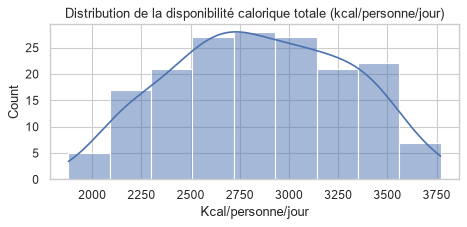

In [9]:
# 3.1 Disponibilité calorique totale

fig, ax = plt.subplots(figsize=(6,3), dpi=80)
sns.histplot(df["Kcal_total"].dropna(), kde=True, ax=ax)
ax.set_title("Distribution de la disponibilité calorique totale (kcal/personne/jour)")
ax.set_xlabel("Kcal/personne/jour")
plt.tight_layout()
plt.show()
plt.close(fig)


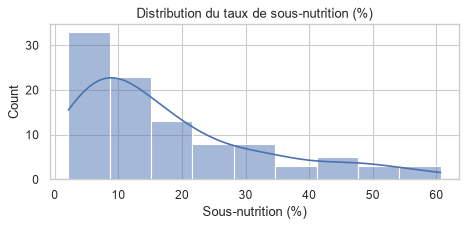

In [10]:
# 3.2 Taux de sous-nutrition

fig, ax = plt.subplots(figsize=(6,3), dpi=80)
sns.histplot(df["Taux_sous_nutrition_pct"].dropna(), kde=True, ax=ax)
ax.set_title("Distribution du taux de sous-nutrition (%)")
ax.set_xlabel("Sous-nutrition (%)")
plt.tight_layout()
plt.show()
plt.close(fig)
